In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)



# Importing Libraries

The required Python libraries were imported for:
- data manipulation,
- numerical analysis,
- and data visualisation.

In [51]:
df = pd.read_csv("QVI_data.csv")

# Loading the Dataset

The transactional dataset was loaded into Python for analysis.

The dataset contains:
- store information,
- transaction dates,
- customer purchases,
- product quantities,
- and sales revenue.

The data will be used to create monthly performance metrics for each store.


In [52]:
df.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


In [54]:
df["DATE"] = pd.to_datetime(df["DATE"])

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   LYLTY_CARD_NBR    264834 non-null  int64         
 1   DATE              264834 non-null  datetime64[ns]
 2   STORE_NBR         264834 non-null  int64         
 3   TXN_ID            264834 non-null  int64         
 4   PROD_NBR          264834 non-null  int64         
 5   PROD_NAME         264834 non-null  object        
 6   PROD_QTY          264834 non-null  int64         
 7   TOT_SALES         264834 non-null  float64       
 8   PACK_SIZE         264834 non-null  int64         
 9   BRAND             264834 non-null  object        
 10  LIFESTAGE         264834 non-null  object        
 11  PREMIUM_CUSTOMER  264834 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(6), object(4)
memory usage: 24.2+ MB


In [56]:
df["YEAR_MONTH"] = df["DATE"].dt.to_period("M")

In [57]:
df[["DATE", "YEAR_MONTH"]].head()

,DATE,YEAR_MONTH
0,2018-10-17,2018-10
1,2018-09-16,2018-09
2,2019-03-07,2019-03
3,2019-03-08,2019-03
4,2018-11-02,2018-11


# Data Preparation

To support the analysis, transaction dates were converted into a monthly format using YEAR_MONTH.

This allows store performance to be analysed consistently over time.

Additional metrics were also created to evaluate customer behaviour and sales performance.

In [58]:
store_metrics = df.groupby(
    ["STORE_NBR", "YEAR_MONTH"]
).agg({
    "TOT_SALES": "sum",
    "LYLTY_CARD_NBR": "nunique",
    "TXN_ID": "nunique",
    "PROD_QTY": "sum"
}).reset_index()

In [59]:
store_metrics.rename(columns={
    "TOT_SALES": "total_sales",
    "LYLTY_CARD_NBR": "customers",
    "TXN_ID": "transactions",
    "PROD_QTY": "total_qty"
}, inplace=True)

In [60]:
store_metrics["txn_per_customer"] = (
    store_metrics["transactions"]
    / store_metrics["customers"]
)

In [61]:
store_metrics["chips_per_customer"] = (
    store_metrics["total_qty"]
    / store_metrics["customers"]
)

In [62]:
store_metrics["avg_price_per_unit"] = (
    store_metrics["total_sales"]
    / store_metrics["total_qty"]
)

In [63]:
store_metrics.head()

,STORE_NBR,YEAR_MONTH,total_sales,customers,transactions,total_qty,txn_per_customer,chips_per_customer,avg_price_per_unit
0,1,2018-07,206.9,49,52,62,1.061224,1.265306,3.337097
1,1,2018-08,176.1,42,43,54,1.023810,1.285714,3.261111
2,1,2018-09,278.8,59,62,75,1.050847,1.271186,3.717333
3,1,2018-10,188.1,44,45,58,1.022727,1.318182,3.243103
4,1,2018-11,192.6,46,47,57,1.021739,1.239130,3.378947


# Monthly Store Metrics

Monthly performance metrics were calculated for each store.

The following KPIs were created:
- total sales revenue,
- total number of customers,
- total transactions,
- total quantity sold,
- transactions per customer,
- chips purchased per customer,
- average price per unit.

These metrics provide a comprehensive view of store performance.


In [64]:
trial_stores = [77, 86, 88]

In [65]:
pretrial = store_metrics[
    store_metrics["YEAR_MONTH"] < "2019-02"
]

In [66]:
pretrial[
    pretrial["STORE_NBR"].isin(trial_stores)
].head()

,STORE_NBR,YEAR_MONTH,total_sales,customers,transactions,total_qty,txn_per_customer,chips_per_customer,avg_price_per_unit
880,77,2018-07,296.8,51,55,84,1.078431,1.647059,3.533333
881,77,2018-08,255.5,47,48,74,1.021277,1.574468,3.452703
882,77,2018-09,225.2,42,44,70,1.047619,1.666667,3.217143
883,77,2018-10,204.5,37,38,52,1.027027,1.405405,3.932692
884,77,2018-11,245.3,41,44,67,1.073171,1.634146,3.661194


# Pre-Trial Period Selection

The pre-trial period was isolated to identify stores with similar behaviour before the trial began.

This step is important because control stores should behave similarly to trial stores before the implementation of the trial strategy.

The pre-trial period includes all months before February 2019.

In [67]:
sales_pivot = pretrial.pivot_table(
    index="YEAR_MONTH",
    columns="STORE_NBR",
    values="total_sales"
)

In [68]:
sales_pivot.head()

STORE_NBR,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272
YEAR_MONTH,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-07,206.9,150.8,1205.70,1399.9,812.0,260.0,1024.7,381.6,289.7,892.00,NaN,429.6,811.8,46.9,742.6,113.8,485.7,326.6,729.1,269.2,409.4,309.2,890.8,719.2,414.6,1245.0,470.1,754.00,309.2,879.8,NaN,761.4,1045.6,335.8,124.2,1014.20,471.60,301.6,866.0,1332.0,216.4,27.3,1003.8,23.7,981.2,253.0,290.30,929.4,1099.7,314.4,116.2,28.3,229.8,480.8,889.6,674.6,839.6,1627.20,1267.6,1106.6,38.4,983.6,1053.2,515.4,1013.4,371.6,859.4,313.1,956.60,920.2,1098.6,1323.6,361.5,206.0,1092.5,NaN,296.8,810.8,1080.10,1029.9,1235.9,348.5,792.4,511.4,13.9,892.20,315.0,1310.0,219.8,235.4,827.7,1080.4,940.00,1053.40,357.4,848.20,128.7,18.5,1027.0,876.6,782.4,196.3,817.0,928.9,1042.80,805.4,242.7,884.0,698.1,224.9,998.8,918.4,945.00,358.9,835.0,2.6,799.40,1074.4,98.7,391.7,864.4,1105.4,104.9,1039.80,331.6,43.9,1036.8,738.6,1273.80,267.4,52.3,1021.8,419.20,24.4,118.8,1034.40,822.4,36.5,8.5,272.8,457.0,344.30,716.0,388.0,12.0,755.60,692.3,418.0,428.0,155.0,1067.6,1092.0,929.80,924.6,1024.6,1045.4,28.0,26.8,894.8,35.5,889.8,188.6,853.2,1457.0,1143.3,236.3,1075.80,217.9,523.8,302.2,820.8,451.00,337.6,964.6,287.2,9.6,952.0,934.0,816.6,1379.90,388.4,870.2,983.8,225.6,141.3,253.9,234.4,137.5,829.4,826.2,34.3,NaN,1111.10,227.50,876.2,363.2,20.3,1299.6,497.2,1107.2,628.2,1266.8,40.4,320.6,3.0,934.2,680.60,723.6,1210.4,2.6,698.2,1098.4,182.4,375.2,1130.4,1329.8,36.8,897.8,244.1,956.3,944.6,930.4,19.2,865.0,1470.00,885.8,326.8,876.0,976.8,1102.5,1026.7,290.7,459.7,533.40,952.0,1448.4,1086.3,367.9,401.7,838.8,450.0,344.4,15.3,375.2,403.4,852.4,386.6,250.4,1161.5,439.40,NaN,391.0,156.4,254.1,256.2,1062.8,16.2,979.4,453.0,1150.3,747.9,38.7,232.6,247.8,127.3,6.2,224.00,982.0,962.80,956.6,433.10
2018-08,176.1,193.8,1079.75,1259.5,745.1,203.2,1119.9,383.0,327.5,878.65,NaN,360.8,756.9,46.8,840.2,149.2,353.3,273.6,737.8,195.7,510.1,201.3,952.1,792.7,340.3,1092.8,526.9,753.95,382.3,935.8,NaN,751.0,934.8,343.7,147.6,1078.05,547.75,283.9,919.2,1208.0,209.8,44.9,1005.7,NaN,669.1,240.7,407.85,851.1,840.7,292.4,208.3,40.3,255.1,384.2,910.3,634.5,915.4,1043.75,932.5,1064.6,27.9,792.4,986.6,374.3,965.0,484.8,902.9,303.7,983.85,860.8,972.1,1243.7,310.6,135.9,1070.4,NaN,255.5,786.8,924.05,952.8,1073.3,326.7,799.8,449.1,NaN,764.05,301.2,1323.8,185.5,224.5,916.1,998.1,1162.25,1277.45,394.0,917.35,95.0,14.8,925.8,866.0,986.4,255.1,881.9,923.7,799.85,868.7,401.4,828.3,761.4,272.6,974.8,1009.9,870.95,322.2,832.4,14.4,755.95,991.1,248.0,294.1,892.5,1353.0,200.9,1114.75,314.3,39.7,910.1,898.7,1233.95,233.4,24.2,916.1,432.65,33.3,173.2,888.95,707.4,34.1,24.3,225.3,506.6,421.85,703.2,309.9,48.0,674.45,763.5,469.9,413.1,135.5,971.1,1019.7,1193.35,782.7,1017.8,904.1,29.8,14.7,756.2,32.5,887.1,183.1,920.2,1206.6,876.6,206.6,922.35,238.2,332.6,394.2,758

In [69]:
trial_store = 77

correlations = sales_pivot.corrwith(
    sales_pivot[trial_store]
)

c:\Users\Onkabetse N\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\Onkabetse N\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\Onkabetse N\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


# Importance of Magnitude Comparison

During the analysis, it was observed that correlation alone was insufficient for selecting control stores.

Some stores showed similar sales movement patterns but operated at very different sales levels.

To improve control-store selection, average monthly sales were also compared to ensure stores were similar in overall business size.

This improved the reliability of the comparisons.

In [70]:
correlations.sort_values(ascending=False).head(10)

STORE_NBR
31     1.000000
77     1.000000
11     1.000000
71     0.914106
233    0.903774
119    0.867664
17     0.842668
3      0.806644
41     0.783232
50     0.763866
dtype: float64

In [71]:
correlations = correlations.drop(trial_store)

In [72]:
top_controls = correlations.sort_values(
    ascending=False
).head(5)

print(top_controls)

STORE_NBR
31     1.000000
11     1.000000
71     0.914106
233    0.903774
119    0.867664
dtype: float64


In [73]:
trial_store = 88

correlations = sales_pivot.corrwith(
    sales_pivot[trial_store]
)

correlations = correlations.drop(trial_store)

top_controls = correlations.sort_values(
    ascending=False
).head(10)

print(top_controls)

STORE_NBR
159    0.903186
204    0.885774
134    0.864293
1      0.813636
253    0.811838
91     0.776688
61     0.748929
178    0.731857
188    0.716752
161    0.706581
dtype: float64


c:\Users\Onkabetse N\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\Onkabetse N\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\Onkabetse N\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


# Correlation Analysis

Pearson correlation was used to compare monthly sales patterns between stores.

Correlation values range between:
- 1 = perfect positive relationship,
- 0 = no relationship,
- -1 = opposite relationship.

Stores with the highest positive correlation were considered the strongest control candidates.

In [74]:
def plot_store_comparison(trial_store, control_store):

    trial_data = pretrial[
        pretrial["STORE_NBR"] == trial_store
    ]

    control_data = pretrial[
        pretrial["STORE_NBR"] == control_store
    ]

    plt.figure(figsize=(12,6))

    plt.plot(
        trial_data["YEAR_MONTH"].astype(str),
        trial_data["total_sales"],
        marker='o',
        label=f"Trial Store {trial_store}"
    )

    plt.plot(
        control_data["YEAR_MONTH"].astype(str),
        control_data["total_sales"],
        marker='o',
        label=f"Control Store {control_store}"
    )

    plt.xticks(rotation=45)

    plt.title(
        f"Pre-Trial Sales Comparison: Store {trial_store} vs {control_store}"
    )

    plt.ylabel("Total Sales")
    plt.xlabel("Month")

    plt.legend()

    plt.show()

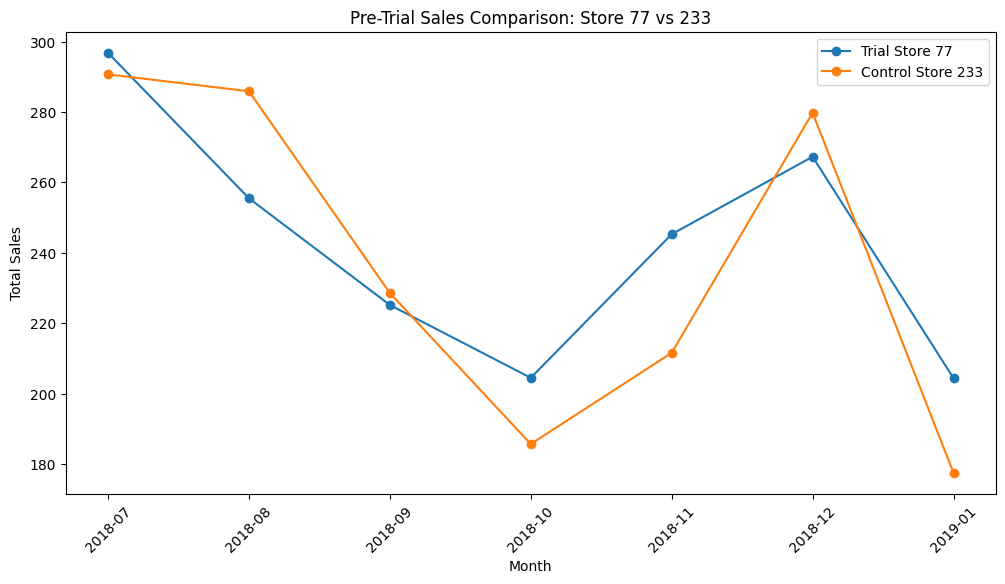

In [75]:
plot_store_comparison(77, 233)

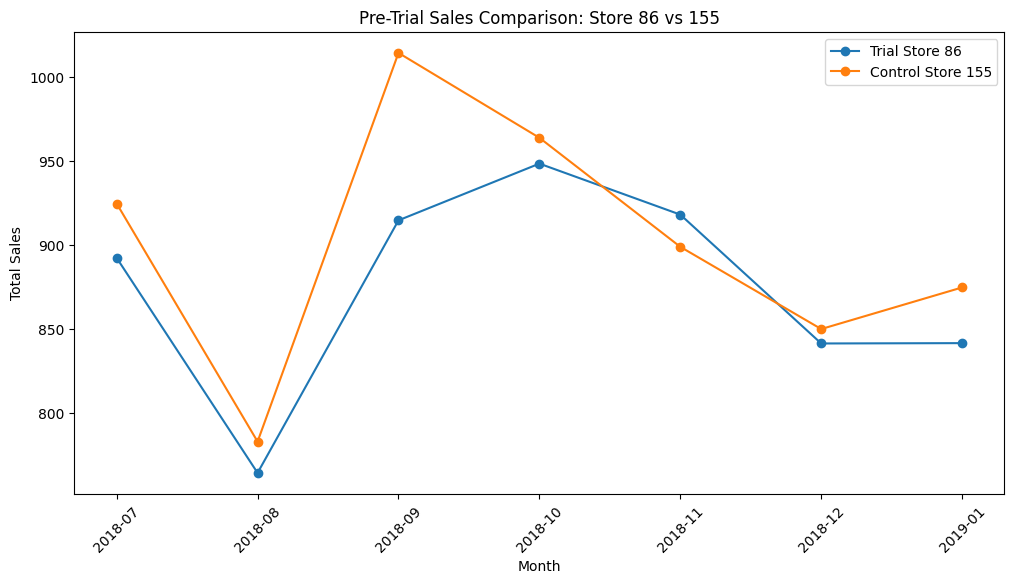

In [76]:
plot_store_comparison(86, 155)

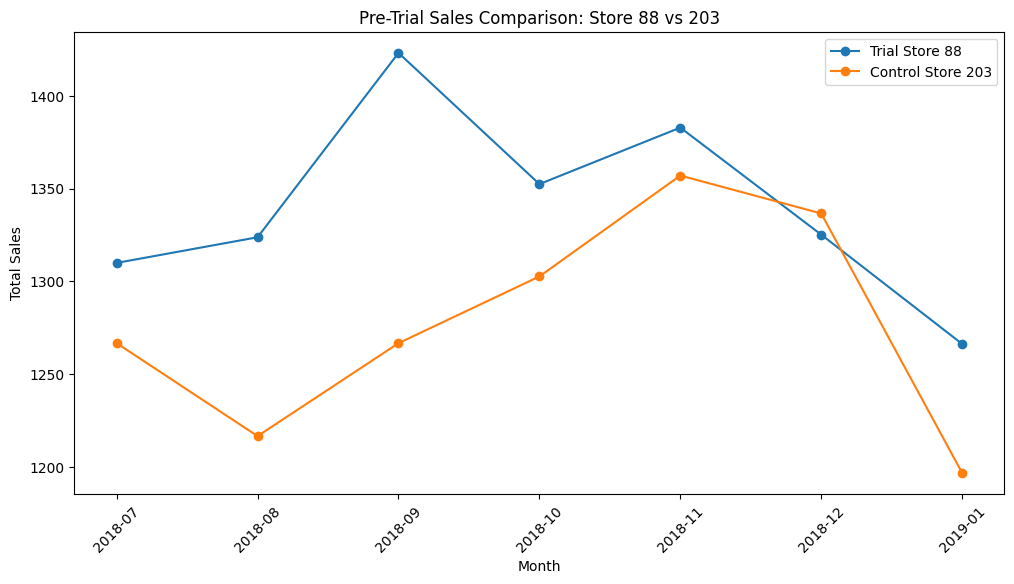

In [77]:
plot_store_comparison(88, 203)

# Visual Validation of Control Stores

Visualisations were created to compare pre-trial sales trends between trial and control stores.

This step helped confirm whether selected control stores followed similar movement patterns over time.

Visual validation is important because it allows trends and inconsistencies to be identified more clearly than numerical metrics alone.

In [78]:
avg_sales = pretrial.groupby("STORE_NBR")[
    "total_sales"
].mean()

print(avg_sales.sort_values(ascending=False).head())

STORE_NBR
226    1462.735714
88     1340.514286
237    1338.428571
165    1319.685714
58     1311.250000
Name: total_sales, dtype: float64


In [79]:
similar_size = avg_sales[
    (avg_sales > 1200) &
    (avg_sales < 1400)
]

print(similar_size)

STORE_NBR
4      1303.857143
26     1209.057143
40     1266.685714
58     1311.250000
72     1216.928571
88     1340.514286
165    1319.685714
199    1236.342857
203    1277.671429
237    1338.428571
Name: total_sales, dtype: float64


In [80]:
trial_store = 88

candidate_stores = [4,26,40,58,72,165,199,203,237]

correlations = sales_pivot.corrwith(
    sales_pivot[trial_store]
)

correlations = correlations.loc[candidate_stores]

print(
    correlations.sort_values(
        ascending=False
    )
)

STORE_NBR
203    0.508001
237    0.308479
26     0.300009
58     0.122810
40    -0.147851
199   -0.533545
165   -0.547126
72    -0.719298
4     -0.745566
dtype: float64


c:\Users\Onkabetse N\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\Onkabetse N\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\Onkabetse N\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [81]:
trial_period = store_metrics[
    store_metrics["YEAR_MONTH"] >= "2019-02"
]

In [82]:
def compare_trial_control(trial_store, control_store):

    trial_data = trial_period[
        trial_period["STORE_NBR"] == trial_store
    ]

    control_data = trial_period[
        trial_period["STORE_NBR"] == control_store
    ]

    comparison = pd.merge(
        trial_data,
        control_data,
        on="YEAR_MONTH",
        suffixes=("_trial", "_control")
    )

    comparison["sales_difference"] = (
        comparison["total_sales_trial"]
        - comparison["total_sales_control"]
    )

    comparison["percent_difference"] = (
        comparison["sales_difference"]
        / comparison["total_sales_control"]
    ) * 100

    return comparison

In [83]:
comparison_77 = compare_trial_control(77, 233)

comparison_86 = compare_trial_control(86, 155)

comparison_88 = compare_trial_control(88, 203)

# Store 77 Control Selection

Store 233 was selected as the control store for Trial Store 77.

The store demonstrated:
- strong correlation,
- similar sales magnitude,
- and comparable movement patterns during the pre-trial period.

The visual comparison confirmed that Store 233 was a suitable benchmark for evaluating Store 77 during the trial period.



# Store 86 Control Selection

Store 155 was selected as the control store for Trial Store 86.

The stores displayed:
- similar sales behaviour,
- comparable sales ranges,
- and closely aligned trends before the trial period.

This indicates that Store 155 is an appropriate control store for comparison.



# Store 88 Control Selection

Initial correlation analysis identified Store 159 as a possible control candidate for Store 88.

However, visual analysis revealed that Store 159 operated at a significantly lower sales magnitude, making it unsuitable for comparison.

Additional analysis using average monthly sales identified Store 203 as a stronger control candidate.


In [84]:
def plot_trial_performance(comparison, trial_store):

    plt.figure(figsize=(12,6))

    plt.plot(
        comparison["YEAR_MONTH"].astype(str),
        comparison["total_sales_trial"],
        marker='o',
        label=f"Trial Store {trial_store}"
    )

    plt.plot(
        comparison["YEAR_MONTH"].astype(str),
        comparison["total_sales_control"],
        marker='o',
        label="Control Store"
    )

    plt.xticks(rotation=45)

    plt.title(
        f"Trial vs Control Performance: Store {trial_store}"
    )

    plt.ylabel("Total Sales")

    plt.xlabel("Month")

    plt.legend()

    plt.show()

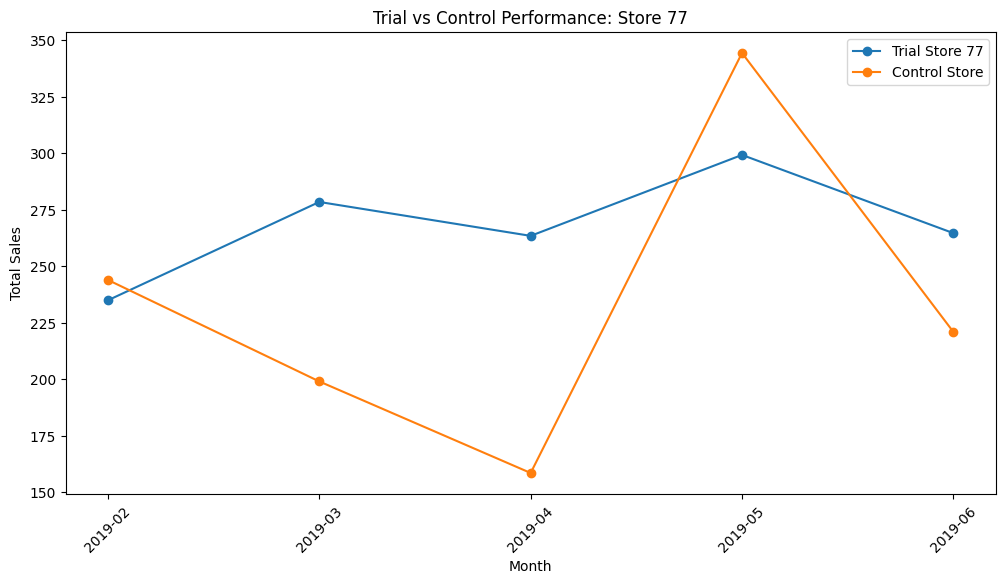

In [85]:
plot_trial_performance(comparison_77, 77)

# Trial Store 77 Performance

Store 77 outperformed Control Store 233 during most of the trial period.

Sales remained relatively stable and generally exceeded the control store across multiple months.

This suggests that the trial likely contributed positively to sales performance.

The trial at Store 77 appears successful and may be suitable for broader rollout.

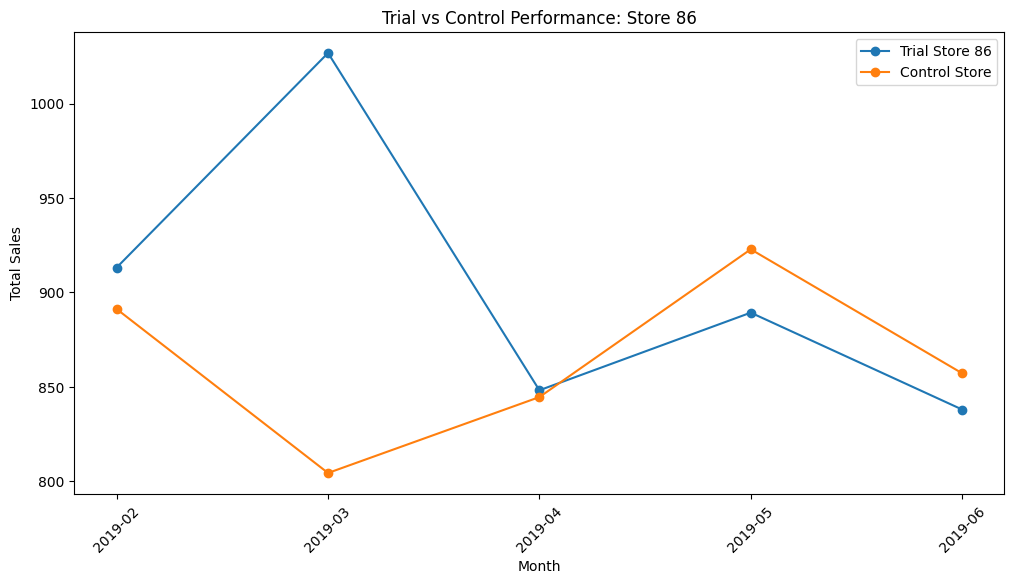

In [86]:
plot_trial_performance(comparison_86, 86)

# Trial Store 86 Performance

Store 86 demonstrated strong performance early in the trial period, particularly during March 2019.

However, performance became less consistent in later months, with the control store occasionally outperforming the trial store.

This suggests that the trial may have had a temporary positive effect, but further optimisation may be required for sustained impact.

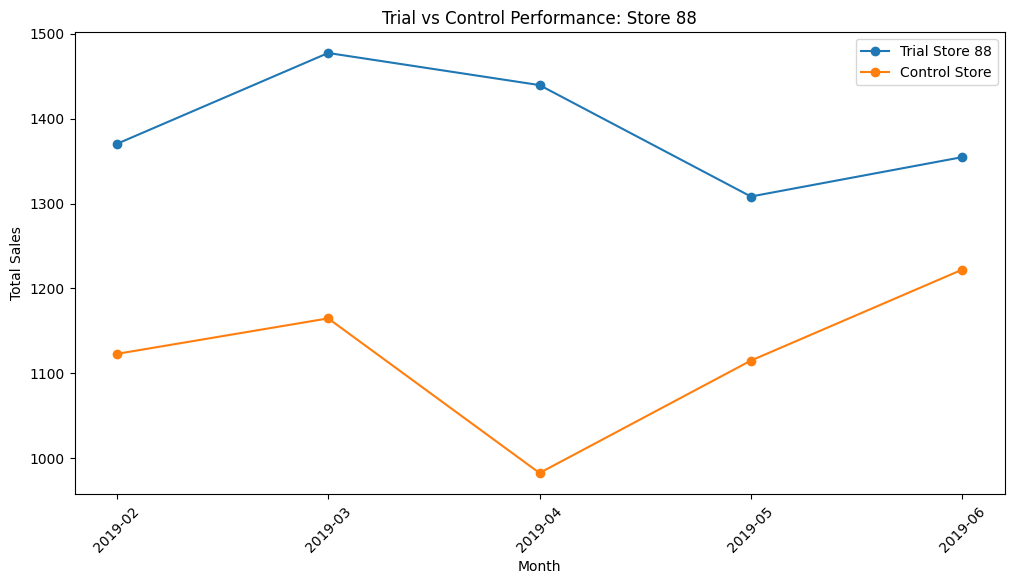

In [87]:
plot_trial_performance(comparison_88, 88)

# Trial Store 88 Performance

Store 88 consistently outperformed Control Store 203 throughout the trial period.

Sales remained significantly higher across all months, indicating strong and sustained performance improvement.

Among all trial stores, Store 88 demonstrated the clearest evidence of positive trial impact.

The trial strategy used in Store 88 should be considered for wider implementation.

# Overall Findings

The analysis indicates that:
- Stores 77 and 88 experienced positive sales uplift during the trial period,
- while Store 86 demonstrated more moderate and inconsistent improvement.

The project also demonstrated the importance of using multiple analytical techniques when selecting control stores, including:
- correlation analysis,
- sales magnitude comparison,
- and visual trend validation.

# Overall Findings

The analysis indicates that:
- Stores 77 and 88 experienced positive sales uplift during the trial period,
- while Store 86 demonstrated more moderate and inconsistent improvement.

The project also demonstrated the importance of using multiple analytical techniques when selecting control stores, including:
- correlation analysis,
- sales magnitude comparison,
- and visual trend validation.